In [8]:
import mhn
import sys
sys.path.append("../MetMHN")
import pandas as pd
import numpy as np
import jax.numpy as jnp

from metmhn.regularized_optimization import score
from metmhn.model import MetMHN


log_theta = pd.read_csv("../metmhn-analyses/2024-07-A-trr-extension/data/luad_g14_20muts.csv", index_col=0)
obs1 = log_theta.iloc[0, :]
obs2 = log_theta.iloc[1, :]

log_theta.drop(index=[0, 1], inplace=True)
log_theta = log_theta.to_numpy()
log_theta[-1, -1] = 0 # set seeding base rate to 1 for now

metmhn_model = MetMHN(log_theta, obs1, obs2)

seeding_log_theta = log_theta.copy()
seeding_log_theta[:, -1] = 0
seeding_log_theta[-1, :-1] = obs1[:-1]
seeding_log_theta[-1, -1] = 1
omhn_seeding = mhn.model.oMHN(np.vstack([seeding_log_theta, np.hstack([log_theta[-1, :-1], 0])]))

pt_log_theta = log_theta.copy()
pt_log_theta[:- 1, -1] = 0
omhn_pt = mhn.model.oMHN(np.vstack([pt_log_theta, obs1]))

omhn_mt = mhn.model.oMHN(np.vstack([log_theta, obs2]))

In [11]:
pt_log_theta.shape

(21, 21)

(<matplotlib.image.AxesImage at 0x7f47b057f970>,
 <matplotlib.colorbar.Colorbar at 0x7f47b023d0f0>)

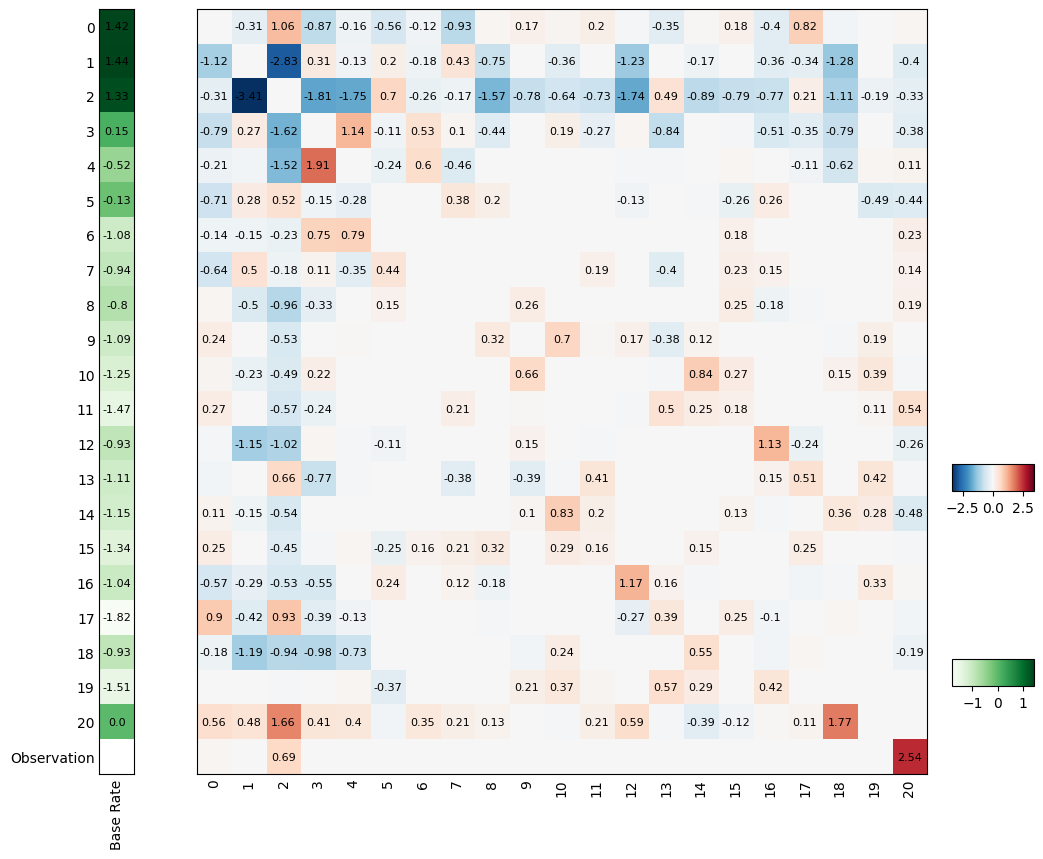

In [20]:
omhn_mt.plot()

In [12]:
state = np.array([
    0, 0, # 0
    0, 1, # 1
    0, 1, # 2
    0, 0, # 3
    0, 0, # 4
    0, 0, # 5
    # 1, 1, # 6
    1, 0,
    0, 0, # 7
    0, 0, # 8
    0, 0, # 9
    0, 0, # 10
    0, 0, # 11
    0, 0, # 12
    0, 0, # 13
    0, 0, # 14
    0, 0, # 15
    0, 0, # 16
    0, 0, # 17
    0, 1, # 18
    0, 0, # 19
    1     # 20
    ], dtype=np.int32)
len(state)

41

In [13]:
log_theta.shape

(21, 21)

In [15]:
# Obsorder
# 0: PT = MT 
# 1: MT > PT
# 2: PT < MT

# Metstatus
# 0: absent
# 1: present
# 2: isMetastasis
# 3: paired

np.exp(score(
        log_theta=jnp.array(log_theta),
        log_d_p=obs1.to_numpy(),
        log_d_m=obs2.to_numpy(),
        dat=np.hstack([state, [0, 3]]).reshape(1, -1),
        perc_met=1))

3.0557330994445857e-10

The probabilites do not match at the moment...

In [16]:
# compute_marginal_likelihood wants a probability vector as p0
final_pt_state = state[::2]
final_mt_state = np.hstack([state[1::2], state[-1]])

pt_split_distribution = np.zeros(1 << final_pt_state.sum(), dtype=float)
pt_split_distribution[1 << (final_pt_state.sum() - 1)] = 1
mt_split_distribution = np.zeros(1 << final_mt_state.sum(), dtype=float)
mt_split_distribution[1 << (final_mt_state.sum() - 1)] = 1
omhn_seeding.compute_marginal_likelihood(np.zeros_like(final_pt_state)) *\
    omhn_pt.compute_marginal_likelihood(final_pt_state, p0=pt_split_distribution) * \
    omhn_mt.compute_marginal_likelihood(final_mt_state, p0=mt_split_distribution)


2.827369094565574e-10